lam thay nhieu ma :))
also we will use the majority/plularity voting principle

# Majority Voting
1. Tập dữ liệu huấn luyện được đưa vào $n$ mô hình cơ sở khác nhau ($C_1, C_2, ..., C_n$). Các mô hình này có thể là Decision Tree, SVM, Logistic Regression,...
2. Mỗi mô hình đưa ra một dự đoán nhãn lớp: $\hat{y}_1, \hat{y}_2, ..., \hat{y}_n$.
3. Mô hình kết hợp (Ensemble model) sẽ đếm số phiếu và chọn nhãn được dự đoán nhiều nhất làm kết quả cuối cùng:$$\hat{y} = \text{mode}\{C_1(x), C_2(x), ..., C_n(x)\}$$

## Tại sao Ensemble Learning lại tốt hơn học bình thường?
Sebastian Raschka giải thích sự vượt trội của Ensemble Learning thông qua Định lý Bồi thẩm đoàn Condorcet (Condorcet's Jury Theorem) và các nguyên tắc xác suất cơ bản.

Để một Ensemble model hoạt động hiệu quả hơn một base classifier, các mô hình cơ sở phải đáp ứng hai điều kiện:
- Độc lập (Independent): Các mô hình mắc những lỗi khác nhau (không sai cùng một chỗ).
- Tỷ lệ lỗi (error rate) của mỗi mô hình phải $\varepsilon < 0.5$ (trong bài toán phân loại nhị phân).
## Chứng minh bằng Toán học
Giả sử chúng ta có một hệ thống Ensemble gồm $n = 11$ mô hình cơ sở độc lập. Tỷ lệ lỗi của mỗi mô hình là $\varepsilon = 0.25$ (nghĩa là độ chính xác 75%).

Hệ thống Ensemble (sử dụng Majority Voting) sẽ dự đoán SAI chỉ khi có hơn một nửa số mô hình cơ sở dự đoán sai (tức là từ 6 mô hình trở lên đoán sai). Chúng ta có thể tính xác suất này bằng phân phối nhị thức (Binomial distribution):$$P(y \neq \hat{y}) = \sum_{k=\lceil n/2 \rceil}^{n} \binom{n}{k} \varepsilon^k (1-\varepsilon)^{n-k}$$Với $n = 11$ và $\varepsilon = 0.25$:
- Xác suất mô hình kết hợp đoán sai giảm xuống chỉ còn khoảng 0.034 (Tương đương độ chính xác 96.6%).
- Kết luận: Mặc dù mỗi mô hình chỉ đúng 75%, khi kết hợp lại, độ chính xác đã tăng vọt lên 96.6%.

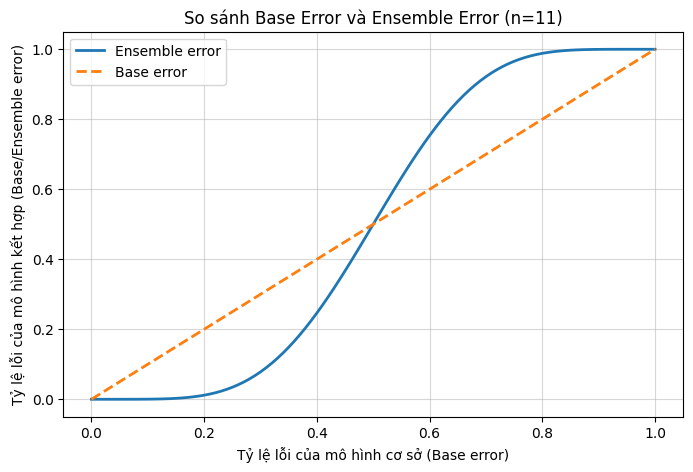

In [ ]:

import numpy as np
import math
from scipy.special import comb
import matplotlib.pyplot as plt

def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.0))
    probs = [comb(n_classifier, k) * error**k * (1-error)**(n_classifier - k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)

error_range = np.arange(0.0, 1.01, 0.01)

ens_errors = [ensemble_error(11, err) for err in error_range]

plt.figure(figsize=(8, 5))
plt.plot(error_range, ens_errors, label='Ensemble error', linewidth=2)
plt.plot(error_range, error_range, linestyle='--', label='Base error', linewidth=2)

plt.xlabel('Tỷ lệ lỗi của mô hình cơ sở (Base error)')
plt.ylabel('Tỷ lệ lỗi của mô hình kết hợp (Base/Ensemble error)')
plt.title('So sánh Base Error và Ensemble Error (n=11)')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.validation import check_is_fitted
from typing import Any

# SỬA LỖI 1: ClassifierMixin phải đứng TRƯỚC BaseEstimator
class MajorityVoteClassifier(ClassifierMixin, BaseEstimator):
    """ Mô hình học kết hợp theo cơ chế bầu chọn đa số (Majority Vote). """

    # Đảm bảo chắc chắn Scikit-Learn nhận diện đây là bộ phân loại (Classifier)
    _estimator_type = "classifier"

    def __init__(self,
                 classifiers: list[Any],
                 vote: str = 'classlabel',
                 weights: list[float] | np.ndarray | None = None) -> None:

        # SỬA LỖI 2: Xóa bỏ mọi logic tính toán, chỉ thực hiện gán tham số
        self.classifiers = classifiers
        self.vote = vote
        self.weights = weights

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'MajorityVoteClassifier':
        """ Khớp (fit) các mô hình cơ sở. """
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f"Tham số vote phải là 'probability' hoặc 'classlabel'. Nhận được: '{self.vote}'")

        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError("Số lượng trọng số (weights) phải khớp với số lượng classifiers.")

        # Mã hóa nhãn (Label encoding)
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_

        # Clone và fit từng mô hình độc lập để tránh rò rỉ trạng thái
        self.classifiers_ = [
            clone(clf).fit(X, self.lablenc_.transform(y))
            for clf in self.classifiers
        ]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Dự đoán nhãn lớp cho dữ liệu X. """
        check_is_fitted(self, ['classifiers_', 'lablenc_'])

        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:
            predictions = np.asarray([clf.predict(X) for clf in self.classifiers_]).T
            maj_vote = np.apply_along_axis(
                lambda x: np.argmax(np.bincount(x, weights=self.weights)),
                axis=1,
                arr=predictions
            )

        return self.lablenc_.inverse_transform(maj_vote)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """ Dự đoán xác suất cho dữ liệu X (Dùng cho Soft Voting). """
        check_is_fitted(self, ['classifiers_', 'lablenc_'])

        probas = np.asarray([clf.predict_proba(X) for clf in self.classifiers_])
        return np.average(probas, axis=0, weights=self.weights)

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

# 1. Chuẩn bị dữ liệu
iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
y = np.where(y == 1, 0, 1)

# Chia tập train/test (stratify giữ nguyên tỷ lệ lớp)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1, stratify=y
)

# 2. Định nghĩa các mô hình cơ sở
# Cập nhật solver cho LogisticRegression (lbfgs là mặc định hiện nay nhưng cứ ghi rõ cho an toàn)
clf1 = LogisticRegression(penalty='l2', C=0.001, solver='lbfgs', random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric='minkowski')

# Tối ưu hóa cú pháp năm 2026: Sử dụng make_pipeline cho mã nguồn ngắn gọn và dễ đọc hơn
pipe1 = make_pipeline(StandardScaler(), clf1)
pipe3 = make_pipeline(StandardScaler(), clf3)

clf_labels = ['Logistic Regression', 'Decision Tree', 'KNN']
print("--- Đánh giá qua Cross-Validation (10-fold) ---")

# 3. Đánh giá mô hình đơn lẻ
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10, scoring='roc_auc')
    print(f"ROC AUC: {scores.mean():.3f} (± {scores.std():.3f}) | Cấu phần: {label}")

# 4. Đánh giá MajorityVoteClassifier tự viết
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3], vote='probability')
clf_labels.append('Majority Voting')

scores = cross_val_score(estimator=mv_clf, X=X_train, y=y_train, cv=10, scoring='roc_auc')
print(f"ROC AUC: {scores.mean():.3f} (± {scores.std():.3f}) | Cấu phần: Tập hợp (Majority Voting)")

--- Đánh giá qua Cross-Validation (10-fold) ---
ROC AUC: 0.917 (± 0.154) | Cấu phần: Logistic Regression
ROC AUC: 0.867 (± 0.183) | Cấu phần: Decision Tree
ROC AUC: 0.850 (± 0.133) | Cấu phần: KNN
ROC AUC: 0.983 (± 0.050) | Cấu phần: Tập hợp (Majority Voting)


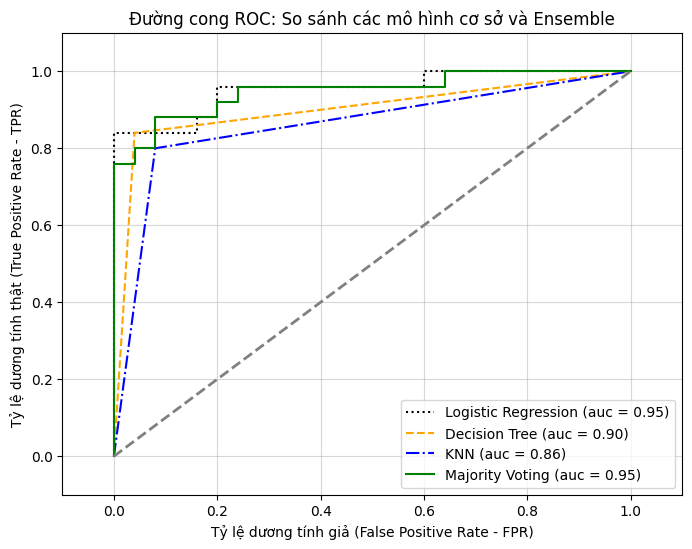

In [ ]:
# [Ô Code Python trong Notebook]
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Đảm bảo danh sách mô hình và nhãn đã đầy đủ
all_clfs = [pipe1, clf2, pipe3, mv_clf]
# clf_labels lúc này nên là: ['Logistic Regression', 'Decision Tree', 'KNN', 'Majority Voting']

# Thiết lập màu sắc và kiểu đường vẽ
colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']

plt.figure(figsize=(8, 6))

# Vẽ đường ROC cho từng mô hình
for clf, label, clr, ls in zip(all_clfs, clf_labels, colors, linestyles):
    # Huấn luyện mô hình và dự đoán xác suất cho lớp positive (nhãn 1)
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]

    # Tính toán FPR, TPR và diện tích AUC
    fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)

    # Vẽ đồ thị
    plt.plot(fpr, tpr, color=clr, linestyle=ls,
             label=f'{label} (auc = {roc_auc:.2f})')

# Vẽ đường chéo đại diện cho việc đoán mò ngẫu nhiên (Random Guessing, AUC = 0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2)

# Căn chỉnh hiển thị
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('Tỷ lệ dương tính giả (False Positive Rate - FPR)')
plt.ylabel('Tỷ lệ dương tính thật (True Positive Rate - TPR)')
plt.title('Đường cong ROC: So sánh các mô hình cơ sở và Ensemble')
plt.legend(loc='lower right')
plt.show()

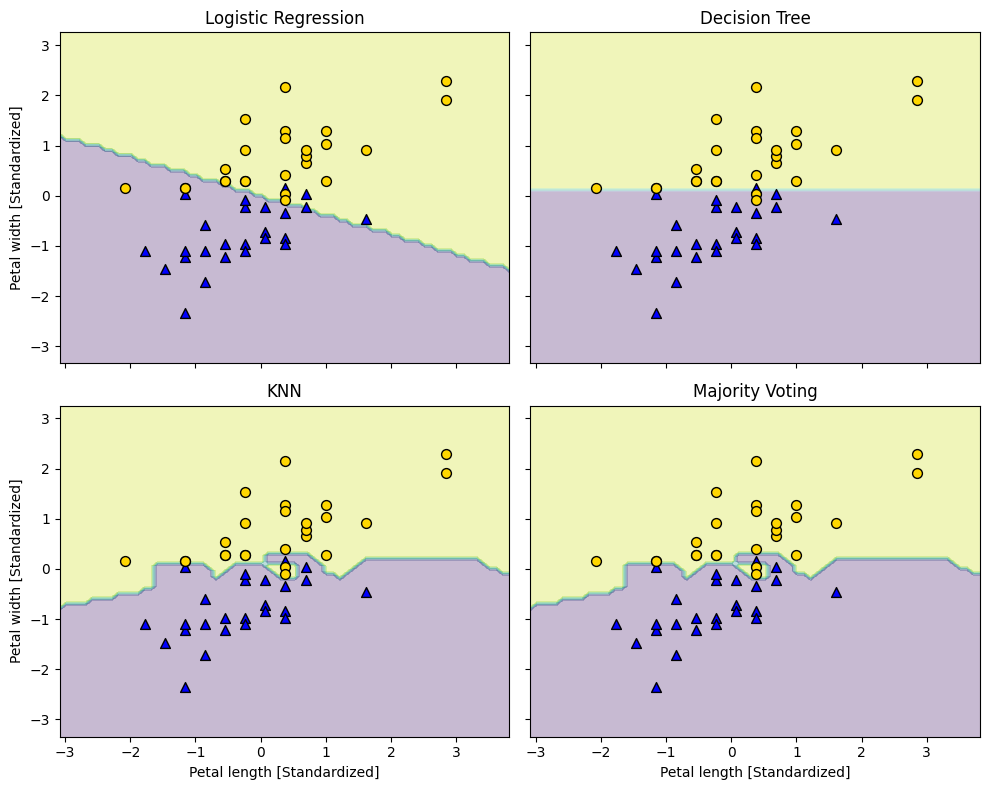

In [ ]:
# [Ô Code Python trong Notebook]
import matplotlib.pyplot as plt
from itertools import product

# 1. Chuẩn hóa dữ liệu ĐỒNG NHẤT từ đầu cho toàn bộ tập train
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
# (Tùy chọn) X_test_std = sc.transform(X_test) - Ở đây ta vẽ trên X_train_std

# 2. Khởi tạo lại các mô hình cơ sở (Bỏ qua Pipeline vì dữ liệu đã chuẩn hóa)
clf1 = LogisticRegression(penalty='l2', C=0.001, solver='lbfgs', random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric='minkowski')

# Khởi tạo Ensemble
mv_clf = MajorityVoteClassifier(classifiers=[clf1, clf2, clf3], vote='probability')

all_clfs = [clf1, clf2, clf3, mv_clf]
clf_labels = ['Logistic Regression', 'Decision Tree', 'KNN', 'Majority Voting']

# 3. Thiết lập không gian đồ thị (Meshgrid)
x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1

# Tạo lưới tọa độ với bước nhảy 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 4. Vẽ đồ thị 2x2
fig, axarr = plt.subplots(nrows=2, ncols=2, sharex='col', sharey='row', figsize=(10, 8))

# Hàm zip kết hợp tọa độ lưới (0,0), (0,1), (1,0), (1,1) với mô hình và nhãn tương ứng
for idx, clf, tt in zip(product([0, 1], [0, 1]), all_clfs, clf_labels):

    # Fit mô hình với dữ liệu đã chuẩn hóa
    clf.fit(X_train_std, y_train)

    # Dự đoán trên toàn bộ không gian lưới tọa độ
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Vẽ vùng quyết định (contour)
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # Vẽ các điểm dữ liệu huấn luyện
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==0, 0], X_train_std[y_train==0, 1],
                                  c='blue', marker='^', s=50, label='Lớp 0', edgecolor='k')
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==1, 0], X_train_std[y_train==1, 1],
                                  c='gold', marker='o', s=50, label='Lớp 1', edgecolor='k')

    axarr[idx[0], idx[1]].set_title(tt)

# Gắn nhãn trục x cho hàng dưới cùng
for ax in axarr[1, :]:
    ax.set_xlabel('Petal length [Standardized]')

# Gắn nhãn trục y cho cột ngoài cùng bên trái
for ax in axarr[:, 0]:
    ax.set_ylabel('Petal width [Standardized]')

plt.tight_layout()
plt.show()

In [ ]:
# [Ô Code Python trong Notebook]
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV

# 1. Khởi tạo VotingClassifier của Scikit-Learn (Thay thế class tự viết)
# Gán tên cụ thể ('lr', 'dt', 'knn') để dễ dàng gọi trong lưới tham số
mv_clf_sklearn = VotingClassifier(
    estimators=[('lr', pipe1), ('dt', clf2), ('knn', pipe3)],
    voting='soft'  # Tương đương với vote='probability'
)

# Tùy chọn: Bạn có thể bỏ comment dòng dưới đây để xem danh sách toàn bộ các khóa tham số
print(mv_clf_sklearn.get_params().keys())

# 2. Thiết lập không gian tìm kiếm siêu tham số (Parameter Grid)
# - Thử nghiệm độ sâu của Decision Tree (max_depth = 1 hoặc 2)
# - Thử nghiệm tham số C của Logistic Regression bên trong Pipeline 'lr'
params = {
    'dt__max_depth': [1, 2],
    'lr__logisticregression__C': [0.001, 0.1, 100.0]
}

# 3. Chạy GridSearchCV
# Lưu ý: Tham số iid=False trong sách cũ đã bị loại bỏ khỏi Scikit-Learn hiện đại
grid = GridSearchCV(
    estimator=mv_clf_sklearn,
    param_grid=params,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1 # Sử dụng tất cả các luồng CPU để chạy nhanh hơn
)

print("Đang tìm kiếm lưới siêu tham số... (Grid Search in progress)\n")
grid.fit(X_train, y_train)

# 4. In kết quả đẹp mắt theo chuẩn Python hiện đại (f-string)
print("--- Kết quả chi tiết ---")
cv_results = grid.cv_results_
for mean_score, std_score, current_params in zip(cv_results['mean_test_score'],
                                                 cv_results['std_test_score'],
                                                 cv_results['params']):
    # Tính độ lệch chuẩn +/- tương tự trong sách
    std_adjusted = std_score / 2.0
    print(f"ROC AUC: {mean_score:.3f} (± {std_adjusted:.2f}) | Tham số: {current_params}")

print("\n" + "="*50)
print(f"⭐ Tổ hợp tham số tốt nhất: {grid.best_params_}")
print(f"⭐ Điểm ROC AUC cao nhất:  {grid.best_score_:.3f}")
print("="*50)

dict_keys(['estimators', 'flatten_transform', 'n_jobs', 'verbose', 'voting', 'weights', 'lr', 'dt', 'knn', 'lr__memory', 'lr__steps', 'lr__transform_input', 'lr__verbose', 'lr__standardscaler', 'lr__logisticregression', 'lr__standardscaler__copy', 'lr__standardscaler__with_mean', 'lr__standardscaler__with_std', 'lr__logisticregression__C', 'lr__logisticregression__class_weight', 'lr__logisticregression__dual', 'lr__logisticregression__fit_intercept', 'lr__logisticregression__intercept_scaling', 'lr__logisticregression__l1_ratio', 'lr__logisticregression__max_iter', 'lr__logisticregression__multi_class', 'lr__logisticregression__n_jobs', 'lr__logisticregression__penalty', 'lr__logisticregression__random_state', 'lr__logisticregression__solver', 'lr__logisticregression__tol', 'lr__logisticregression__verbose', 'lr__logisticregression__warm_start', 'dt__ccp_alpha', 'dt__class_weight', 'dt__criterion', 'dt__max_depth', 'dt__max_features', 'dt__max_leaf_nodes', 'dt__min_impurity_decrease', 

Bagging


In [ ]:
# [Ô Code Python trong Notebook]
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Tải bộ dữ liệu Wine từ UCI Machine Learning Repository
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)
df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']

# Để minh họa trực quan 2D và bài toán phân loại nhị phân:
# Ta chỉ lấy lớp 2 và lớp 3, và chỉ dùng 2 đặc trưng (Alcohol và OD280/OD315)
df_wine = df_wine[df_wine['Class label'] != 1]
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values
y = df_wine['Class label'].values

# Mã hóa nhãn (2 và 3 -> 0 và 1)
le = LabelEncoder()
y = le.fit_transform(y)

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
print(f"Số lượng mẫu huấn luyện: {X_train.shape[0]}")

Số lượng mẫu huấn luyện: 95


In [ ]:
# [Ô Code Python trong Notebook]
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Khởi tạo Decision Tree không cắt tỉa (Dễ bị Overfitting)
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=None)

# 2. Khởi tạo Bagging Classifier với 500 cây quyết định
bag = BaggingClassifier(
    estimator=tree,           # Mô hình cơ sở
    n_estimators=500,         # Số lượng mô hình (500 cây)
    max_samples=1.0,          # Lấy mẫu 100% dữ liệu cho mỗi cây (nhưng có hoàn lại)
    bootstrap=True,           # Lấy mẫu có hoàn lại (Bootstrapping)
    n_jobs=-1,                # Chạy đa luồng
    random_state=1
)

# 3. Đánh giá Decision Tree đơn lẻ
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)

print("--- Decision Tree đơn lẻ ---")
print(f"Độ chính xác Train: {tree_train:.3f}")
print(f"Độ chính xác Test:  {tree_test:.3f} (Có dấu hiệu Overfitting rõ rệt!)")

# 4. Đánh giá Bagging
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)

print("\n--- Bagging (500 Trees) ---")
print(f"Độ chính xác Train: {bag_train:.3f}")
print(f"Độ chính xác Test:  {bag_test:.3f} (Đã cải thiện khả năng tổng quát hóa!)")

--- Decision Tree đơn lẻ ---
Độ chính xác Train: 1.000
Độ chính xác Test:  0.833 (Có dấu hiệu Overfitting rõ rệt!)

--- Bagging (500 Trees) ---
Độ chính xác Train: 1.000
Độ chính xác Test:  0.917 (Đã cải thiện khả năng tổng quát hóa!)


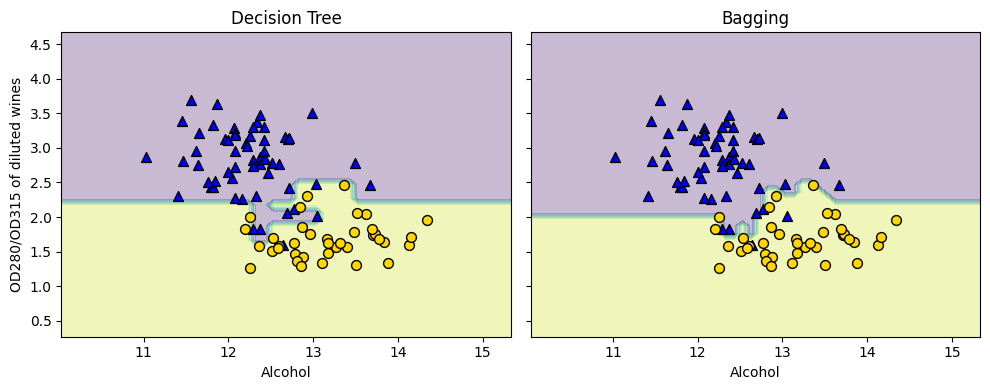

In [ ]:
# [Ô Code Python trong Notebook]
import matplotlib.pyplot as plt

# Tạo lưới không gian 2D
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

fig, axarr = plt.subplots(nrows=1, ncols=2, sharex='col', sharey='row', figsize=(10, 4))

# Trực quan hóa cho 2 mô hình
for idx, clf, tt in zip([0, 1], [tree, bag], ['Decision Tree', 'Bagging']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    axarr[idx].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', marker='^', s=50, edgecolor='k')
    axarr[idx].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='gold', marker='o', s=50, edgecolor='k')
    axarr[idx].set_title(tt)

axarr[0].set_ylabel('OD280/OD315 of diluted wines')
for ax in axarr:
    ax.set_xlabel('Alcohol')

plt.tight_layout()
plt.show()